In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paulrowland/wifi-access-points-with-gps-location/wifi_survey.csv


In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_csv("/kaggle/input/datasets/paulrowland/wifi-access-points-with-gps-location/wifi_survey.csv")

In [12]:
df.shape

(12460, 13)

In [13]:
df.head()

,bssid,recordDate,latitude,longitude,accuracy,signalStrength,ssid,securityType,channel,frequency,capabilities,totalSurveys,inconsistentLocation
0,40:3f:8c:7f:29:bd,1679082542888,52.252118,-2.890032,8.2,-39,PLUSNET-R3C22J_EXT,WPA2,0,2412,[WPA2-PSK-CCMP][RSN-PSK-CCMP][ESS][WPS],9795,0
1,c4:e5:32:27:0c:d8,1679084801821,52.252063,-2.889735,6.3,-25,PLUSNET-R3C22J,WPA2,0,2412,[WPA2-PSK-CCMP][RSN-PSK-CCMP][ESS][WPS],8008,0
2,62:e5:32:27:0c:dc,1679085220270,52.252130,-2.889973,6.6,-25,NaN,WPA2,0,2412,[WPA2-PSK-CCMP][RSN-PSK-CCMP][ESS],2001,0
3,d4:86:60:8e:bd:00,1679085447359,52.252065,-2.888555,6.3,-85,BT-6RC29N,WPA2,2,5180,[WPA2-PSK-CCMP][RSN-PSK-CCMP][ESS][WPS],11,0
4,62:86:60:8e:bd:01,1679085447359,52.252065,-2.888555,6.3,-85,BTWi-fi,OPEN,2,5180,[ESS],11,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12460 entries, 0 to 12459
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bssid                 12460 non-null  object 
 1   recordDate            12460 non-null  int64  
 2   latitude              12460 non-null  float64
 3   longitude             12460 non-null  float64
 4   accuracy              12460 non-null  float64
 5   signalStrength        12460 non-null  int64  
 6   ssid                  10280 non-null  object 
 7   securityType          12460 non-null  object 
 8   channel               12460 non-null  int64  
 9   frequency             12460 non-null  int64  
 10  capabilities          12460 non-null  object 
 11  totalSurveys          12460 non-null  int64  
 12  inconsistentLocation  12460 non-null  int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 1.2+ MB


In [15]:
# Drop rows where lat/lon is missing or clearly invalid
df = df.dropna(subset=["latitude", "longitude"])
df = df[(df["latitude"].between(-90, 90)) & (df["longitude"].between(-180, 180))]
 
# Fill missing SSID
df["ssid"] = df["ssid"].fillna("Unknown")
 
# Flag open vs secured networks
df["is_open"] = (df["securityType"] == "OPEN").astype(int)
 
# Convert recordDate to datetime features (optional enrichment)
df["recordDate"] = pd.to_datetime(df["recordDate"], unit="ms", errors="coerce")
df["hour"] = df["recordDate"].dt.hour
 
print(f"\nClean dataset: {len(df)} records")


Clean dataset: 12460 records


In [16]:
EARTH_RADIUS_M = 6_371_000
EPS_METRES     = 80          # APs within 80 m → same cluster
MIN_SAMPLES    = 5           # minimum APs to form a dense region
 
coords_rad = np.radians(df[["latitude", "longitude"]].values)
 
db_spatial = DBSCAN(
    eps        = EPS_METRES / EARTH_RADIUS_M,
    min_samples= MIN_SAMPLES,
    algorithm  = "ball_tree",
    metric     = "haversine",
    n_jobs     = -1
)
df["cluster_spatial"] = db_spatial.fit_predict(coords_rad)
 
n_clusters_s  = len(set(df["cluster_spatial"])) - (1 if -1 in df["cluster_spatial"].values else 0)
n_noise_s     = (df["cluster_spatial"] == -1).sum()
 
print("\n── Spatial DBSCAN ──────────────────────────────")
print(f"  Clusters found : {n_clusters_s}")
print(f"  Noise points   : {n_noise_s} ({n_noise_s/len(df)*100:.1f}%)")
print(f"  Params: eps={EPS_METRES}m, min_samples={MIN_SAMPLES}")
 


── Spatial DBSCAN ──────────────────────────────
  Clusters found : 138
  Noise points   : 71 (0.6%)
  Params: eps=80m, min_samples=5


In [17]:
features = ["latitude", "longitude", "signalStrength", "channel", "frequency"]
X = df[features].copy()
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
db_enriched = DBSCAN(
    eps        = 0.5,        # in standardised-feature space
    min_samples= 5,
    metric     = "euclidean",
    n_jobs     = -1
)
df["cluster_enriched"] = db_enriched.fit_predict(X_scaled)
 
n_clusters_e = len(set(df["cluster_enriched"])) - (1 if -1 in df["cluster_enriched"].values else 0)
n_noise_e    = (df["cluster_enriched"] == -1).sum()
 
print("\n── Enriched DBSCAN (spatial + RF) ─────────────")
print(f"  Clusters found : {n_clusters_e}")
print(f"  Noise points   : {n_noise_e} ({n_noise_e/len(df)*100:.1f}%)")
print(f"  Features       : {features}")
 


── Enriched DBSCAN (spatial + RF) ─────────────
  Clusters found : 30
  Noise points   : 104 (0.8%)
  Features       : ['latitude', 'longitude', 'signalStrength', 'channel', 'frequency']


In [18]:
 
def silhouette_safe(X, labels, name):
    mask = labels != -1
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        score = silhouette_score(X[mask], labels[mask], sample_size=5000, random_state=42)
        print(f"  Silhouette ({name}): {score:.4f}  (closer to +1 is better)")
    else:
        print(f"  Silhouette ({name}): not calculable (too few clusters)")
 
print("\n── Quality Metrics ─────────────────────────────")
silhouette_safe(coords_rad, df["cluster_spatial"].values,   "spatial")
silhouette_safe(X_scaled,   df["cluster_enriched"].values,  "enriched")


── Quality Metrics ─────────────────────────────
  Silhouette (spatial): 0.6867  (closer to +1 is better)
  Silhouette (enriched): -0.2525  (closer to +1 is better)


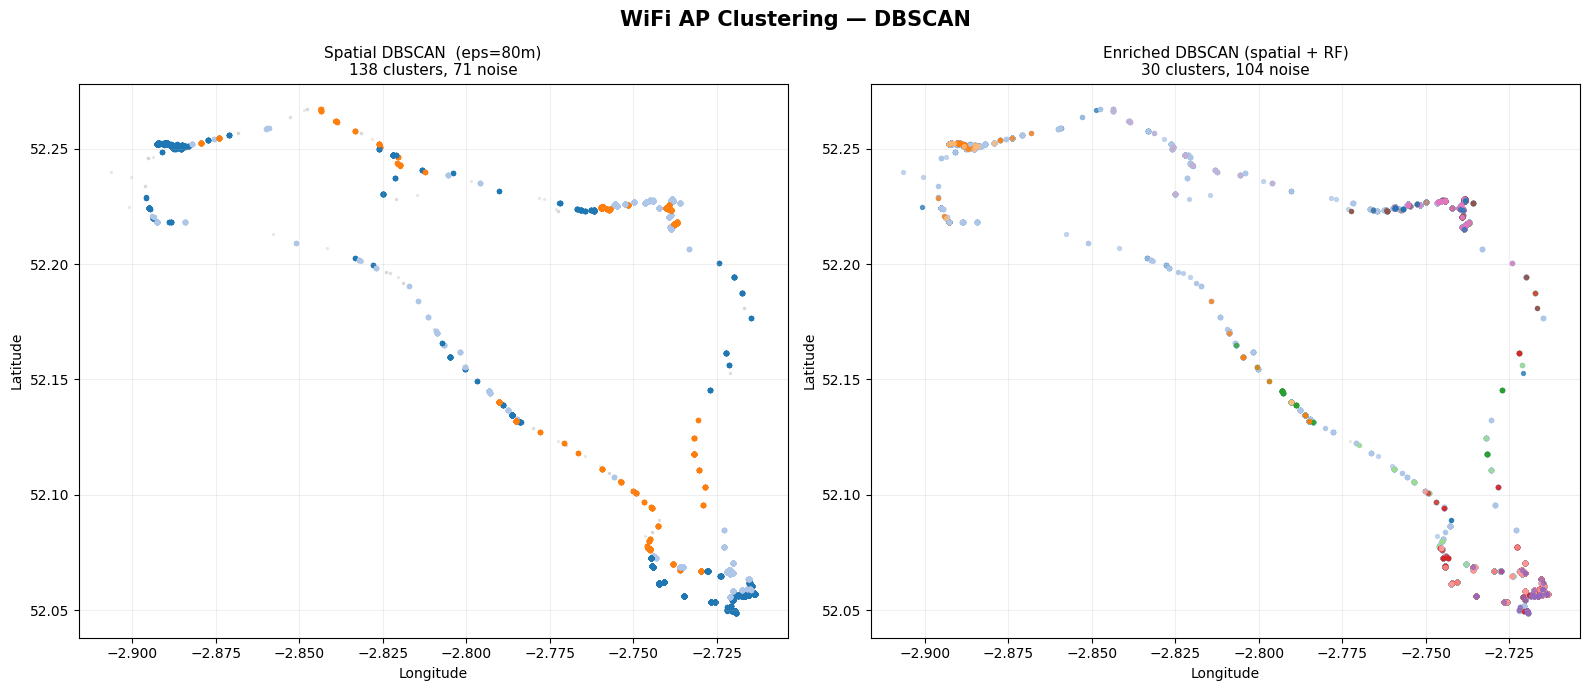

Saved: dbscan_clusters.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("WiFi AP Clustering — DBSCAN", fontsize=15, fontweight="bold")
 
for ax, col, title in zip(
    axes,
    ["cluster_spatial", "cluster_enriched"],
    [f"Spatial DBSCAN  (eps={EPS_METRES}m)", "Enriched DBSCAN (spatial + RF)"]
):
    labels   = df[col].values
    unique_l = sorted(set(labels))
    cmap     = cm.get_cmap("tab20", max(len(unique_l), 1))
 
    # noise in grey
    noise_mask = labels == -1
    ax.scatter(
        df.loc[noise_mask, "longitude"],
        df.loc[noise_mask, "latitude"],
        c="lightgrey", s=2, alpha=0.4, label="Noise"
    )
 
    # clusters
    for i, lbl in enumerate([l for l in unique_l if l != -1]):
        mask = labels == lbl
        ax.scatter(
            df.loc[mask, "longitude"],
            df.loc[mask, "latitude"],
            s=8, alpha=0.7,
            color=cmap(i % 20),
            label=f"C{lbl}" if i < 10 else ""
        )
 
    n_c = len([l for l in unique_l if l != -1])
    ax.set_title(f"{title}\n{n_c} clusters, {noise_mask.sum()} noise", fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2)
 
plt.tight_layout()
plt.savefig("dbscan_clusters.png", dpi=150)
plt.show()
print("Saved: dbscan_clusters.png")